In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mojtaba142/hotel-booking/hotel_booking.csv")

# **Data Exploration**

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe(include = "O").T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


# Check For Missing Values


In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# Handle missing values

In [8]:
#fill the null values on country with unkown
df['country'] = df['country'].fillna('Unknown')

In [9]:
#fill the null values on children with mean
df["children"] = df["children"].fillna(df["children"].median())

# Feature Engineering (Binary Encoding)
Create new columns:
* has_agent
* has_company

Helps in analysis like:

* “Do bookings with agents cancel more?”
* “Do company bookings behave differently?”


In [10]:
# has_agent: 1 if agent exists, 0 if missing
df['has_agent'] = np.where(df['agent'].notna(), 1, 0)

# has_company: 1 if company exists, 0 if missing
df['has_company'] = np.where(df['company'].notna(), 1, 0)

In [11]:
df.drop(['agent', 'company'], axis=1, inplace=True)

In [12]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [13]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card,has_agent,has_company
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677,1,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498,1,0


# Handle logical data issues

there's 180 rows with no adults, children, babies

In [14]:
df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)].shape[0]

180

In [15]:
#flag them to be 1
df['invalid_guest_record'] = ((df['adults'] == 0) & 
                              (df['children'] == 0) & 
                              (df['babies'] == 0)).astype(int)

In [16]:
df[df['invalid_guest_record'] == 1].shape[0]

180

# **ADR handling** 
max = 5400

min = -6.3

In [17]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [18]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['adr'] = df['adr'].clip(lower, upper)

**Handle negative ADR**

In [19]:
df.loc[df['adr'] < 0, 'adr'] = np.nan

In [20]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card,has_agent,has_company,invalid_guest_record
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734,0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677,1,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498,1,0,0


In [21]:
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [22]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [23]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status_date,name,email,phone-number,credit_card,has_agent,has_company,invalid_guest_record,total_nights,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322,0,0,0,0,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157,0,0,0,0,2.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734,0,0,0,1,1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677,1,0,0,1,1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498,1,0,0,2,2.0


In [24]:
#convert month name into number
month_map = {
    'January': 1, 'February': 2, 'March': 3,
    'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9,
    'October': 10, 'November': 11, 'December': 12
}

df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

In [25]:
df['arrival_date'] = pd.to_datetime(
    dict(
        year=df['arrival_date_year'],
        month=df['arrival_month_num'],
        day=df['arrival_date_day_of_month']
    )
)

In [26]:
df.drop(columns=[
    'arrival_date_year', 'arrival_date_month',
    'arrival_date_day_of_month', 'arrival_date_week_number'
], inplace=True)

In [27]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card', 'has_agent', 'has_company',
       'invalid_guest_record', 'total_nights', 'total_guests',
       'arrival_month_num', 'arrival_date'],
      dtype='object')

# Univariate Analysis

**Cancelations**

In [28]:
df['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

/tmp/ipykernel_16/3534371878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='viridis')


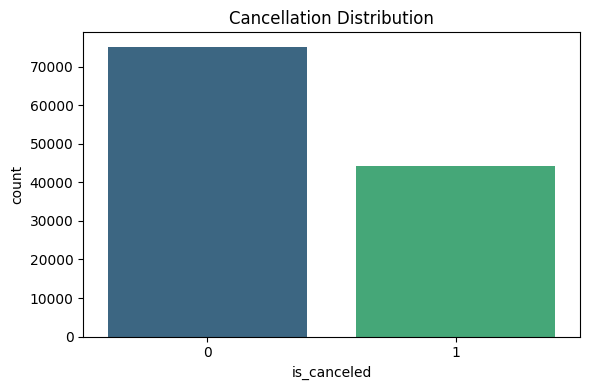

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=df, palette='viridis')
plt.title('Cancellation Distribution')
plt.tight_layout()
plt.show()

**Hotel Type**

In [30]:
df['hotel'].value_counts(normalize=True) * 100

hotel
City Hotel      66.446101
Resort Hotel    33.553899
Name: proportion, dtype: float64

/tmp/ipykernel_16/473474473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hotel', data=df, palette='viridis')


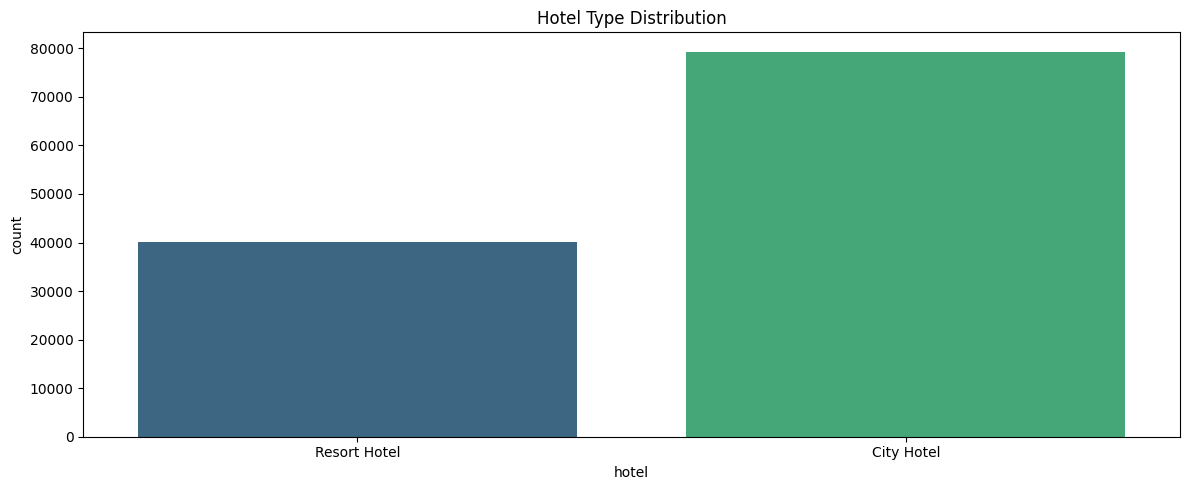

In [31]:
plt.figure(figsize=(12,5))
sns.countplot(x='hotel', data=df, palette='viridis')
plt.title('Hotel Type Distribution')
plt.tight_layout()
plt.show()

**Meals**

In [32]:
df['meal'].value_counts(normalize=True) * 100

meal
BB           77.318033
HB           12.114080
SC            8.920345
Undefined     0.979144
FB            0.668398
Name: proportion, dtype: float64

/tmp/ipykernel_16/2972075236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='meal', data=df, palette='viridis')


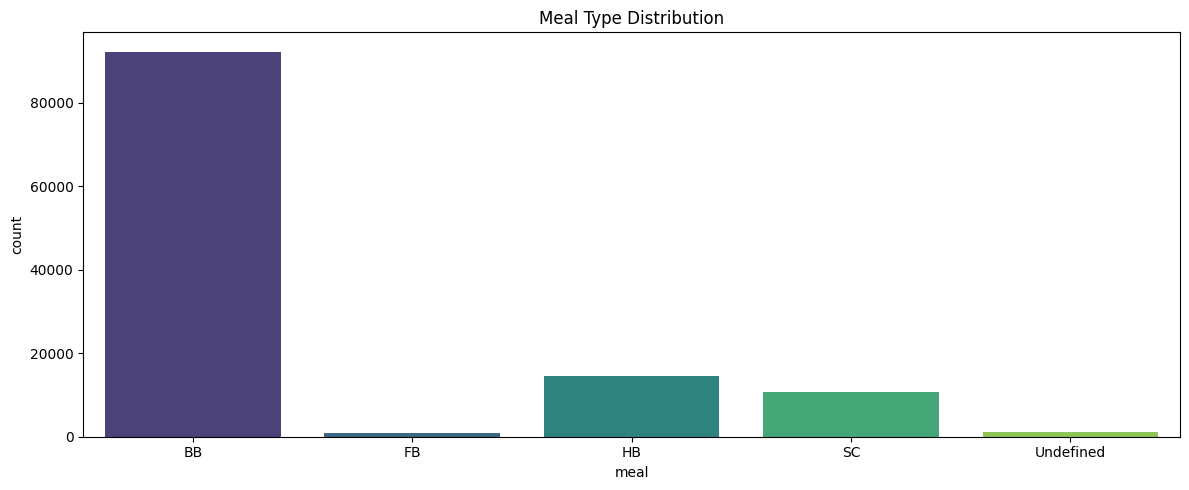

In [33]:
plt.figure(figsize=(12,5))
sns.countplot(x='meal', data=df, palette='viridis')
plt.title('Meal Type Distribution')
plt.tight_layout()
plt.show()

**Customer Type**

In [34]:
df['customer_type'].value_counts(normalize=True) * 100

customer_type
Transient          75.059050
Transient-Party    21.043638
Contract            3.414021
Group               0.483290
Name: proportion, dtype: float64

/tmp/ipykernel_16/2754812535.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='customer_type', data=df, palette='viridis')


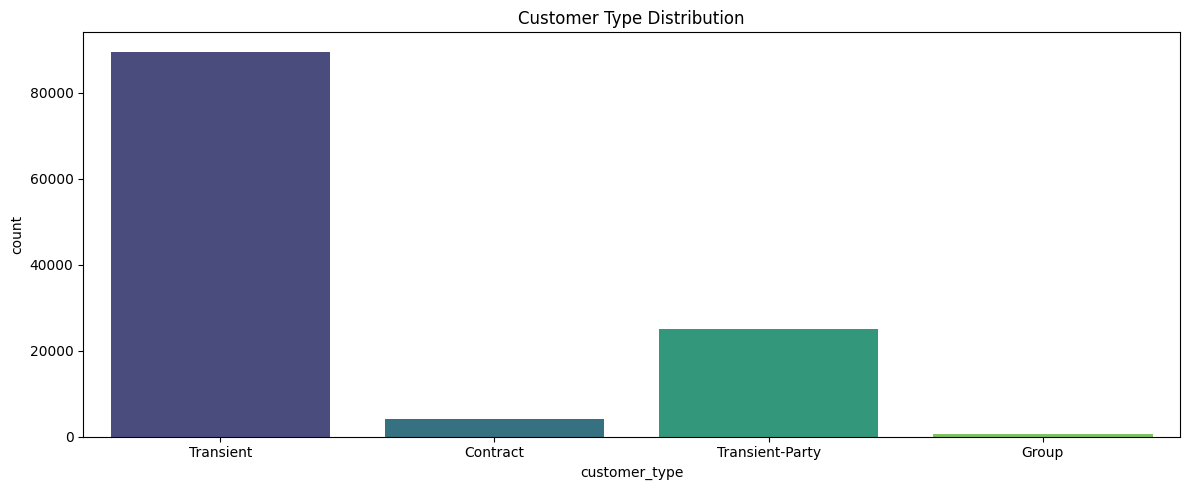

In [35]:
plt.figure(figsize=(12,5))
sns.countplot(x='customer_type', data=df, palette='viridis')
plt.title('Customer Type Distribution')
plt.tight_layout()
plt.show()

**Top 10 Countries**

In [36]:
top_countries = df['country'].value_counts().head(10)

/tmp/ipykernel_16/266363648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index,palette='viridis')


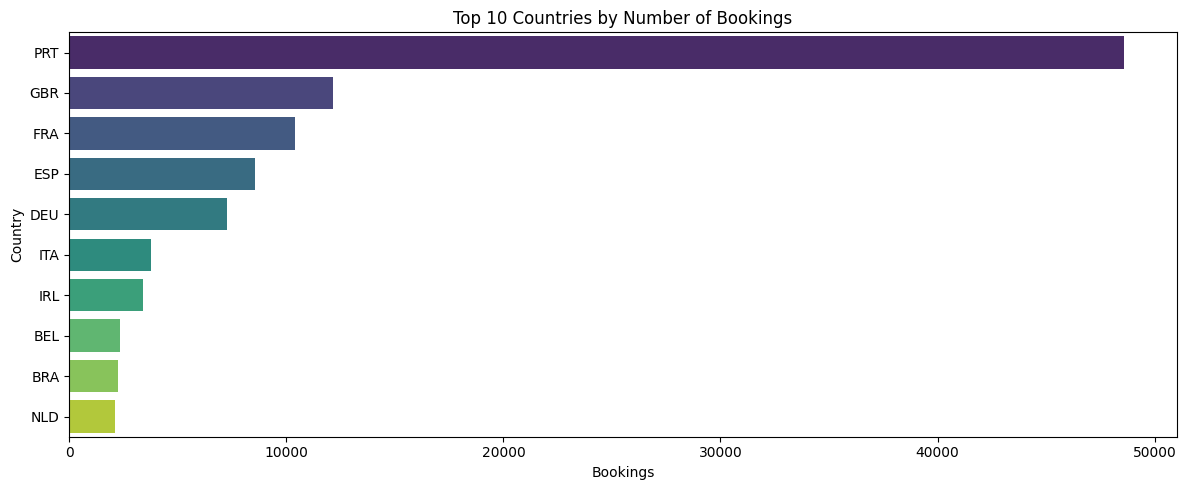

In [37]:
plt.figure(figsize=(12,5))
sns.barplot(x=top_countries.values, y=top_countries.index,palette='viridis')
plt.title('Top 10 Countries by Number of Bookings')
plt.xlabel('Bookings')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**ADR**

In [38]:
df['adr'].describe()

count    119389.000000
mean        100.660201
std          44.688059
min           0.000000
25%          69.290000
50%          94.590000
75%         126.000000
max         211.065000
Name: adr, dtype: float64

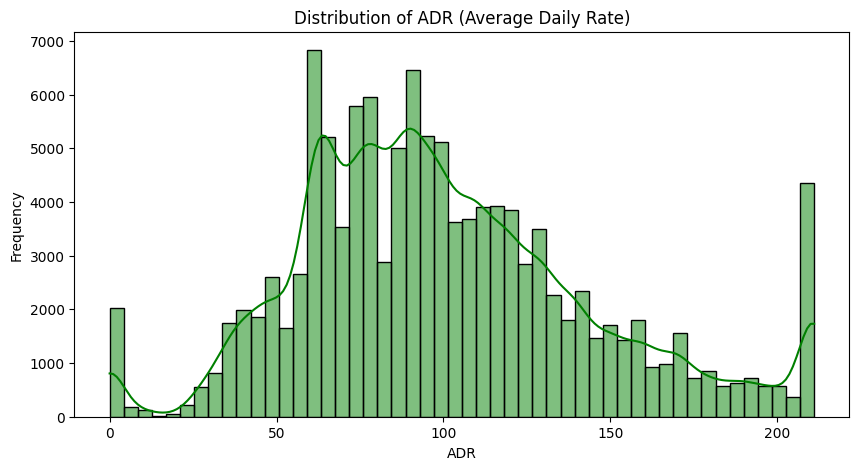

In [39]:
plt.figure(figsize=(10,5))
sns.histplot(df['adr'], bins=50, kde=True, color="green")
plt.title("Distribution of ADR (Average Daily Rate)")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

# Handling Lead Time
**Most values are small/medium:**

* 50% of bookings happen within 69 days

**But a few values are extremely large:**

* up to 737 days (~2 years)

In [40]:
df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

In [41]:
Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['lead_time'] = df['lead_time'].clip(lower, upper)

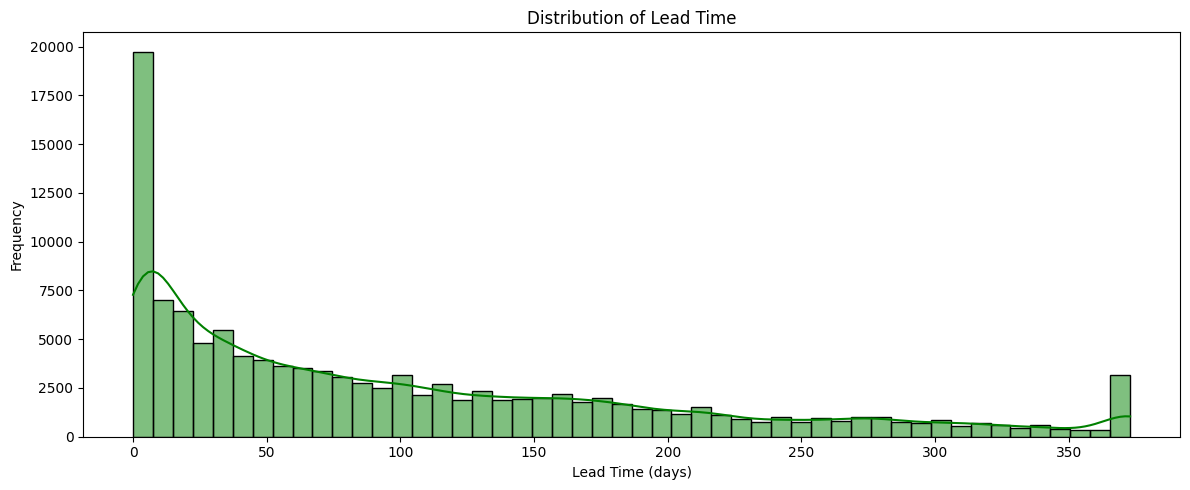

In [42]:
plt.figure(figsize=(12,5))
sns.histplot(df['lead_time'], bins=50, kde=True, color='green')
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

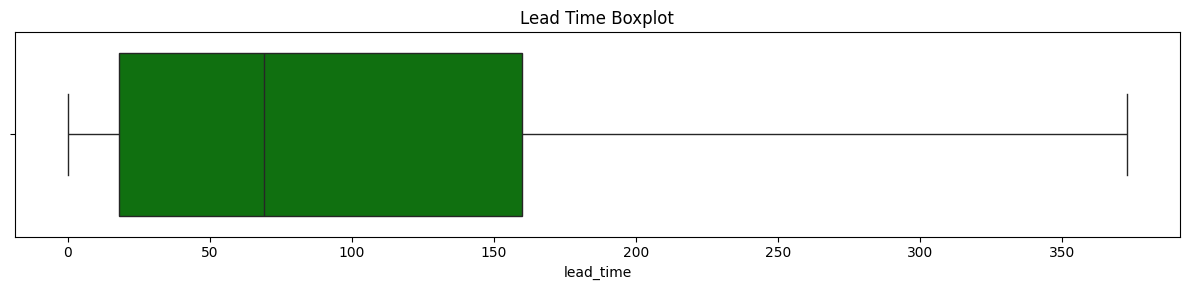

In [43]:
plt.figure(figsize=(12,3))
sns.boxplot(x=df['lead_time'], color='green')
plt.title('Lead Time Boxplot')
plt.tight_layout()
plt.show()

# Bivariate analysis

**Lead Time vs Cancellation**

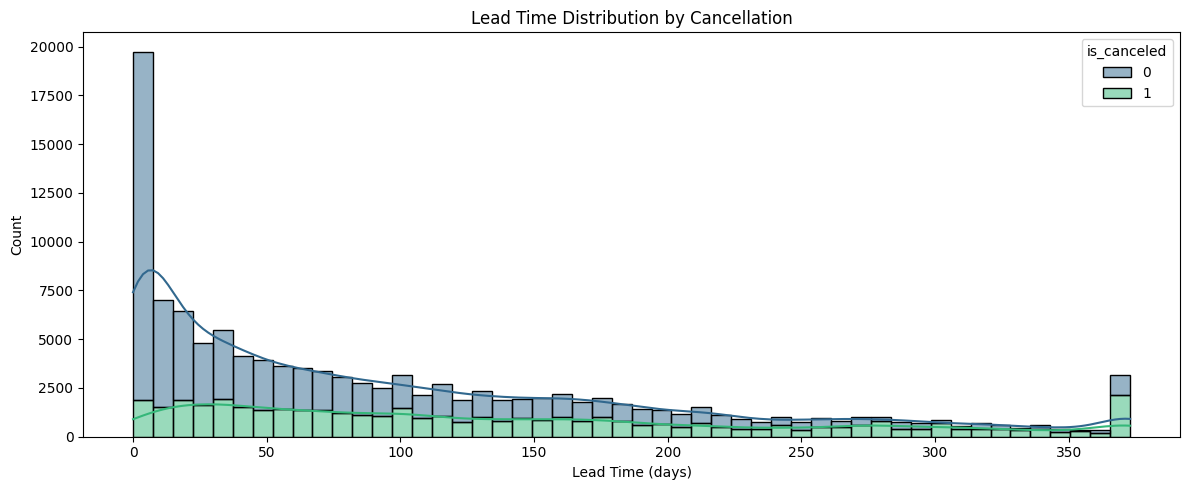

In [44]:
plt.figure(figsize=(12,5))

sns.histplot(data=df, x='lead_time', hue='is_canceled', bins=50, kde=True, palette='viridis', multiple='stack')
plt.title('Lead Time Distribution by Cancellation')
plt.xlabel('Lead Time (days)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Cancelation rate by hotel type**

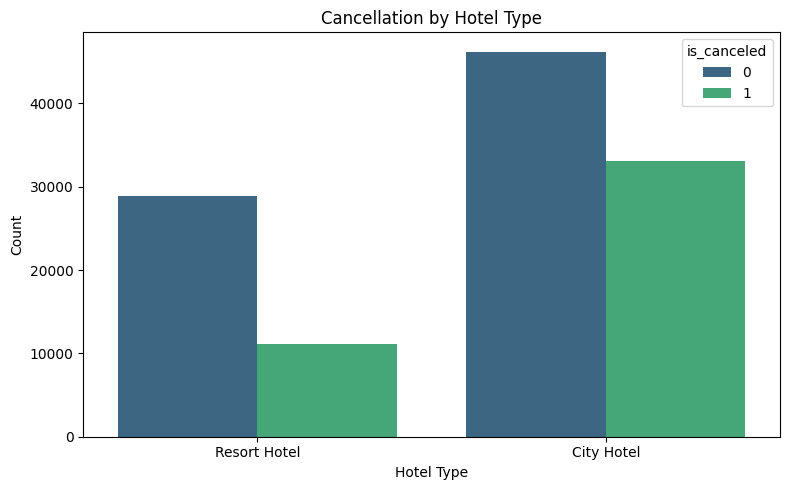

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='hotel', hue='is_canceled', data=df, palette='viridis')
plt.title('Cancellation by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Top 10 countries vs cancelation**

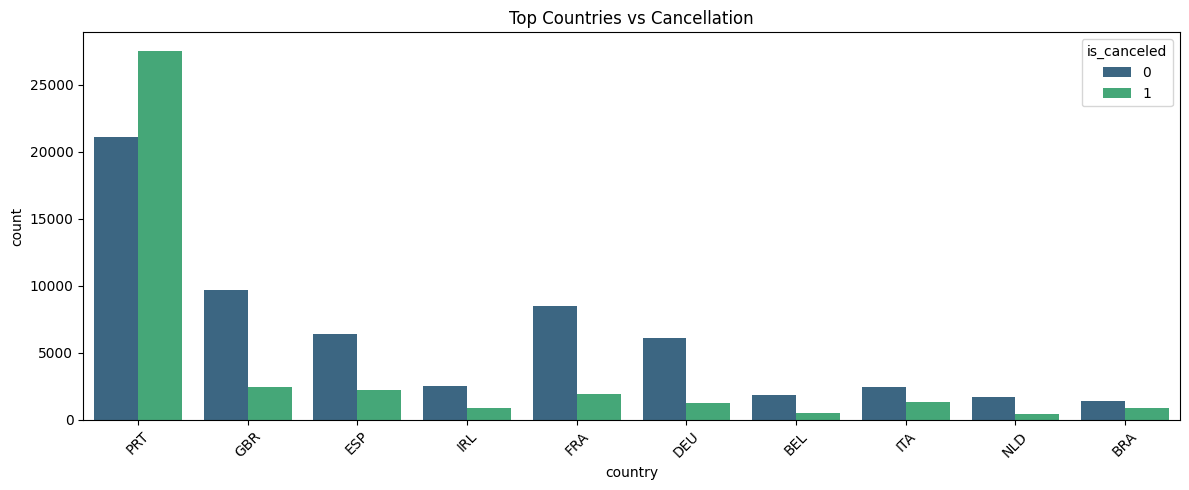

In [46]:
top_countries = df['country'].value_counts().head(10).index
plt.figure(figsize=(12,5))
sns.countplot(data=df[df['country'].isin(top_countries)], x='country', hue='is_canceled', palette='viridis')
plt.title('Top Countries vs Cancellation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**ADR vs Cancelations**

/tmp/ipykernel_16/2251020231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_canceled', y='adr', data=df, palette='viridis')


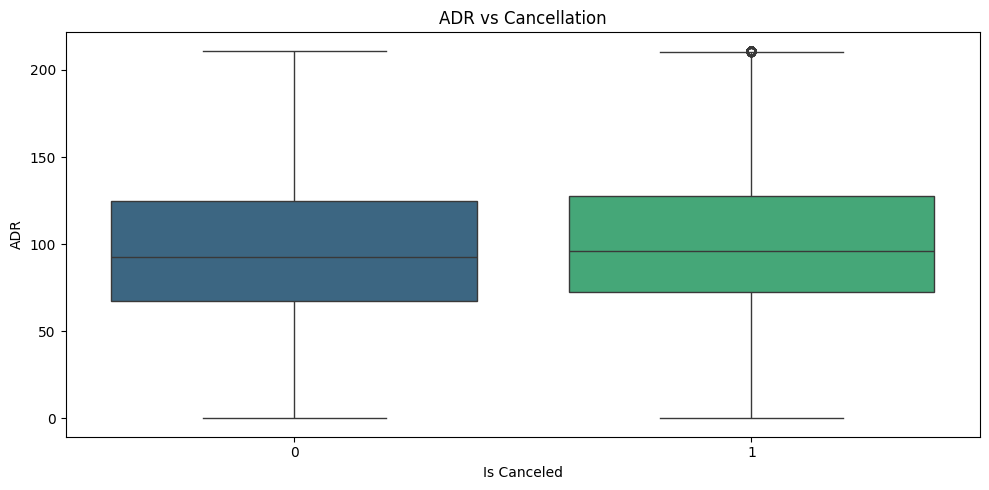

In [47]:
plt.figure(figsize=(10,5))
sns.boxplot(x='is_canceled', y='adr', data=df, palette='viridis')
plt.title('ADR vs Cancellation')
plt.xlabel('Is Canceled')
plt.ylabel('ADR')
plt.tight_layout()
plt.show()

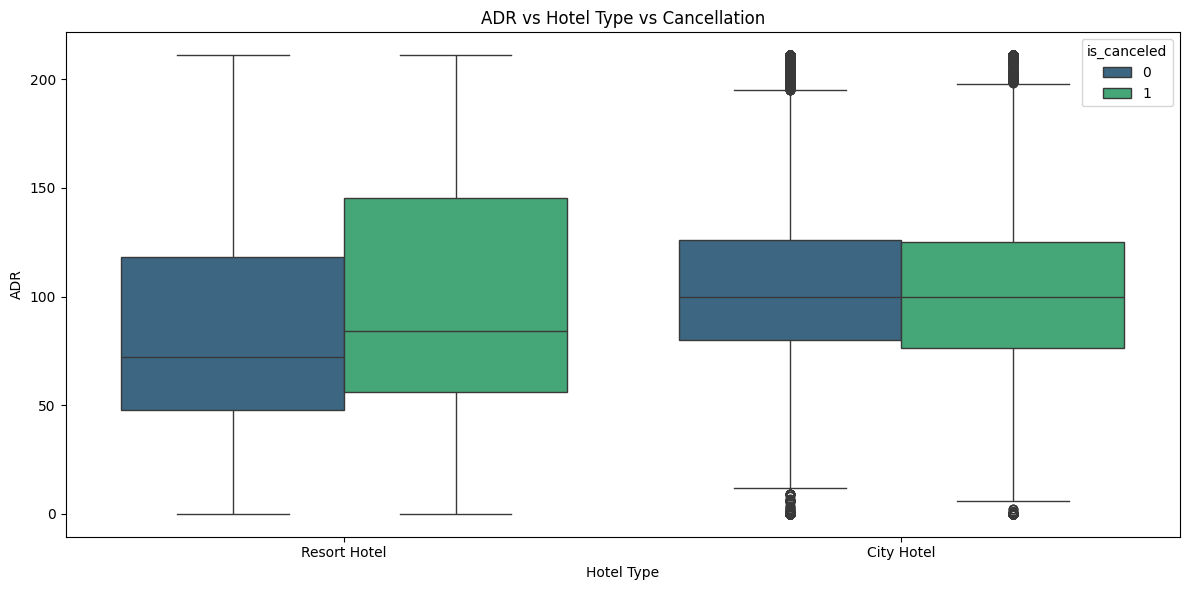

In [48]:
plt.figure(figsize=(12,6))
sns.boxplot(x='hotel', y='adr', hue='is_canceled', data=df, palette='viridis')
plt.title('ADR vs Hotel Type vs Cancellation')
plt.xlabel('Hotel Type')
plt.ylabel('ADR')
plt.tight_layout()
plt.show()

# Which hotel is more expensive?

/tmp/ipykernel_16/1986498207.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hotel', y='adr', data=df, palette='viridis')


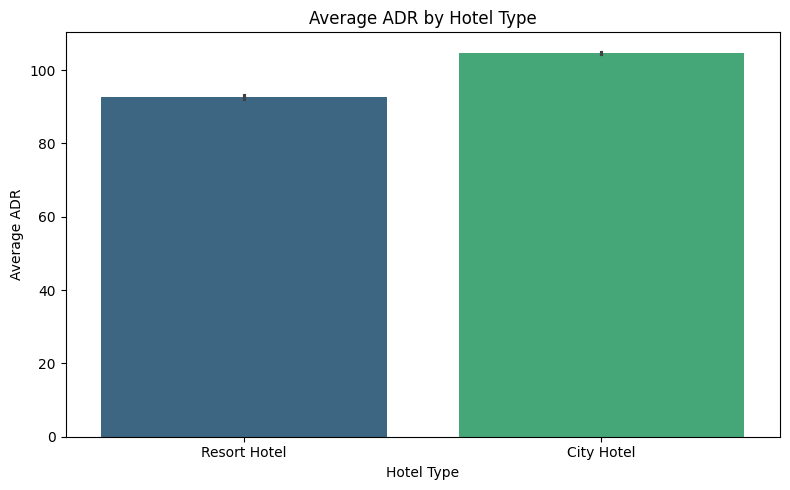

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x='hotel', y='adr', data=df, palette='viridis')

plt.title('Average ADR by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average ADR')
plt.tight_layout()
plt.show()

# ADR by hotel AND cancellation

**Do cancellations happen at higher or lower ADR?**

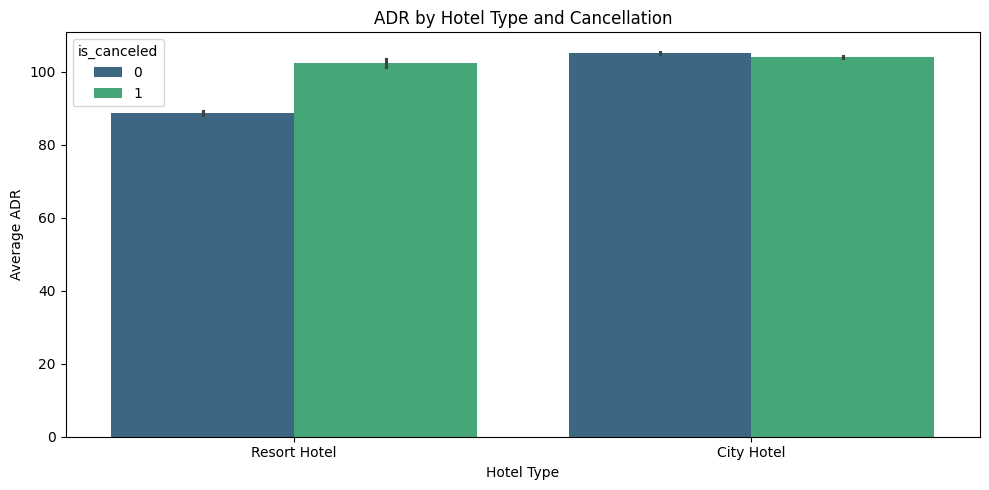

In [50]:
plt.figure(figsize=(10,5))
sns.barplot(x='hotel', y='adr', hue='is_canceled', data=df, palette='viridis')
plt.title('ADR by Hotel Type and Cancellation')
plt.xlabel('Hotel Type')
plt.ylabel('Average ADR')
plt.tight_layout()
plt.show()